In [ ]:
%%capture
!pip install datasets transformers qdrant_client langchain_community

In [ ]:
import re
import uuid
import torch

import numpy as np

from tqdm.auto import tqdm

from datasets import load_dataset
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from qdrant_client import QdrantClient, models

### Загрузка датасета и модели



Данные - [blinoff/kinopoisk](https://huggingface.co/datasets/blinoff/kinopoisk)


> Kinopoisk movie reviews dataset (TOP250 & BOTTOM100 rank lists).
  In total it contains 36,591 reviews from July 2004 to November 2012.



In [ ]:
def process_dataset(sample):
    sample['content'] = sample['content'].replace('\xa0', ' ')
    return sample

dataset = load_dataset("blinoff/kinopoisk", split='train')
dataset = dataset.map(process_dataset)
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

kinopoisk.jsonl:   0%|          | 0.00/143M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36591 [00:00<?, ? examples/s]

Map:   0%|          | 0/36591 [00:00<?, ? examples/s]

Dataset({
    features: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content'],
    num_rows: 36591
})

In [ ]:
dataset[0]

{'part': 'top250',
 'movie_name': 'Блеф (1976)',
 'review_id': '17144',
 'author': 'Come Back',
 'date': datetime.datetime(2011, 9, 24, 0, 0),
 'title': 'Плакали наши денежки ©',
 'grade3': 'Good',
 'grade10': '10',
 'content': '\n"Блеф» — одна из моих самых любимых комедий.\n\nЭтот фильм я наверно смотрел раз сто, нет я конечно блефую, я видел его куда больше. Не могу не выразить своё восхищение главными действующими лицами этого фильма. Начну с Адриано Челентано для которого как я считаю это лучшая роль в кино. Великолепный актёр, неплохой певец, странно что на его родине в Италии его песни мало кто слушает. Ну я думаю что и итальянцы и французы привыкли к тому, что у нас до сих их актёры популярней чем даже на своей родине. Да, такой вот парадокс. Челентано конечно профессионал своего дела, комик с серьёзным выражением лица. Он смешон ещё и потому, что одновременно так серъёзен. Адриано браво!\n\nА теперь несколько слов об Энтони Куине. Да тот самый горбун из Нотр-дама. Собор Парижс

В качестве основной модели возьмем [Qwen2-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2-1.5B-Instruct)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

generation_pipeline = pipeline(
    "text-generation",
    model="Qwen/Qwen2-1.5B-Instruct",
    device=device,
    torch_dtype=torch.float16
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


## QA без RAG

Проверим, насколько хорошо модель отвечает на вопросы без использования RAG.

In [ ]:
def get_answer(query):
  messages = [
    {"role": "user", "content": query},
  ]
  output = generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.9, top_p=0.7)
  answer = output[0]['generated_text'][1]['content']
  print(answer)

In [ ]:
query = 'Какие мультфильмы были созданы студией Pixar'
get_answer(query)

Студия Pixar создала множество отличных мультфильмов, но некоторые из них включают "Терминатор", "Микки Маус", "Суперман", "Владимир Путин и его бабушка", "Звездный путь: Войны небесных судей", "Глобусы" и "Лунная служанка".


In [ ]:
query = 'В каких фильмах снимался Андриано Челентано?'
get_answer(query)

Андриано Челентано является одним из самых известных и успешных актеров Италии, поэтому он снялся в большом количестве фильмов. Однако, конкретные фильмы, которые он снимался в, могут варьироваться в зависимости от того, какой список фильмов вы хотите увидеть. Вот некоторые из его наиболее известных работ:

1. "Джек Рожа" (Jack Rovelli) - 2009 год
2. "Приключения Стормовой Птицы" (Stormy Weather) - 2013 год
3. "Кровавый Лес" (Bloodwoods) - 2015 год
4. "Берег" (Borgo) - 2017 год
5. "Черное Детство" (La Morte Nera) - 2018 год

Это лишь несколько примеров работы Челентано. Он также известен своими работами на русском языке, таких как "Рыцарь", "Следствие", "Ночь на Острове К


##  Добавим RAG

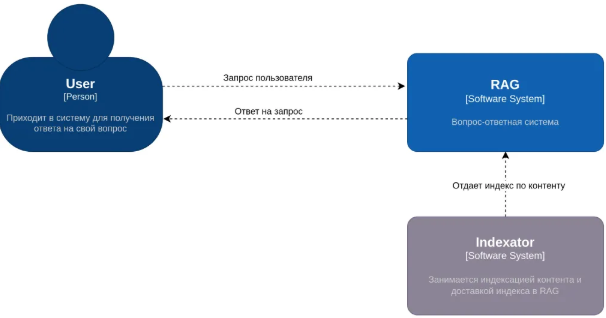

Более подробный пайплайн

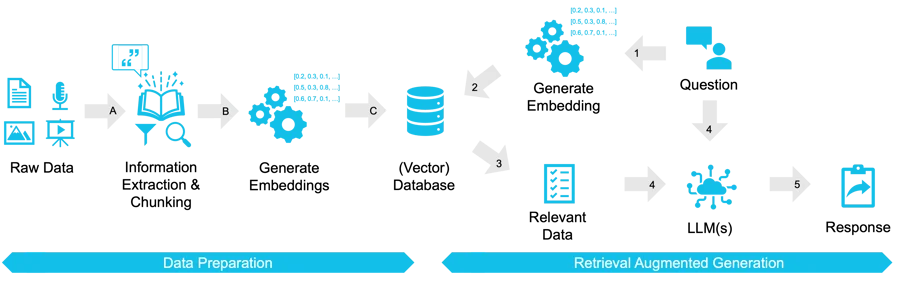

Первый шаг - наполнение векторной базы данных. В качестве модели для создания эмбеддингов возьмем [intfloat/multilingual-e5-large](https://huggingface.co/intfloat/multilingual-e5-large).

In [ ]:
embedding_model = SentenceTransformer("intfloat/multilingual-e5-large", model_kwargs={'torch_dtype': torch.float16})

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

### Выбор векторной базы

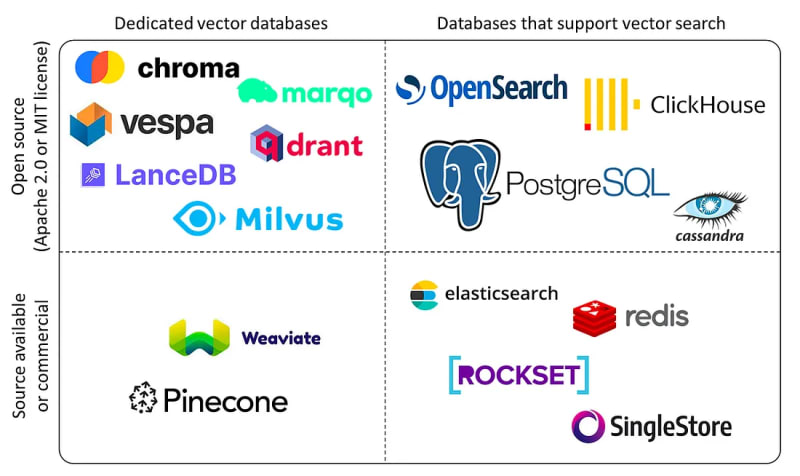

Как выбрать поисковый движок?

- составляем список требований **в конкретном проекте**;
- собираем список кандидатов;
- составляем сводную таблицу по доступному функционалу кандидатов;
- ищем наибольшее пересечение требований и функционала в таблице.

[Vector DB Comparison](https://superlinked.com/vector-db-comparison)

### Qdrant

Построим векторную базу данных с помощью фреймворка Qdrant

Основные особенности:

- Предоставляет спецификации OpenAPI v3 и предварительно построенные клиенты для нескольких языков программирования.

- Использует собственный алгоритм **HNSW** для быстрого и точного поиска векторов.

- Позволяет фильтровать результаты на основе связанных векторных данных.

- Поддерживает различные типы данных, включая сопоставление строк, числовые диапазоны и географические местоположения.

- Разработан для облачных сред с возможностями горизонтального масштабирования.

[Qdrant Benchmarking Vector Databases](https://qdrant.tech/benchmarks/)

### Алгоритмы поиска векторов

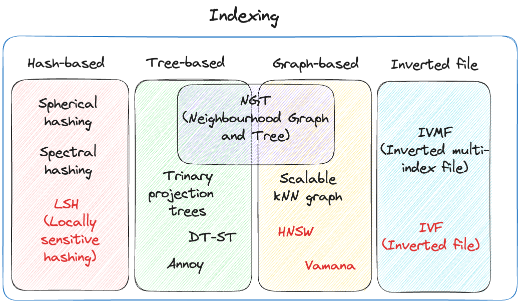

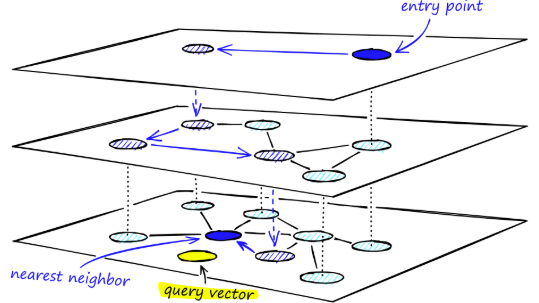

In [ ]:
client = QdrantClient(":memory:")

client.create_collection(
    collection_name="kinopoisk_e5",
    on_disk_payload=True,
    vectors_config=models.VectorParams(
        size=1024,
        distance=models.Distance.COSINE,
        on_disk=True
    ),
)

True

### Как считать расстояние

- евклидово расстояние (L2, самая популярная);
- манхэттенское расстояние (L1);
- скалярное произведение (самая интересная для векторной БД: из него можно вывести косинусную близость, а их обычно смотрят вместе);
- косинусная близость


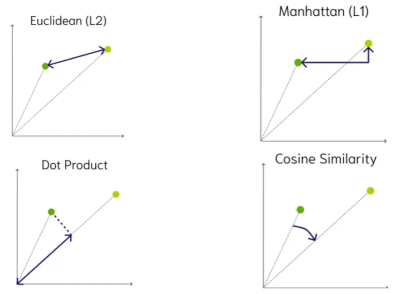

### Разбиение текста на чанки

Для разбиения текста на куски используем `RecursiveCharacterTextSplitter` из библиотеки [langchain](https://github.com/langchain-ai/langchain). Мы будем делить текст на куски примерно по 1000 символов рекурсивно.

[Какие еще есть варианты?](https://python.langchain.com/v0.1/docs/modules/data_connection/document_transformers/)

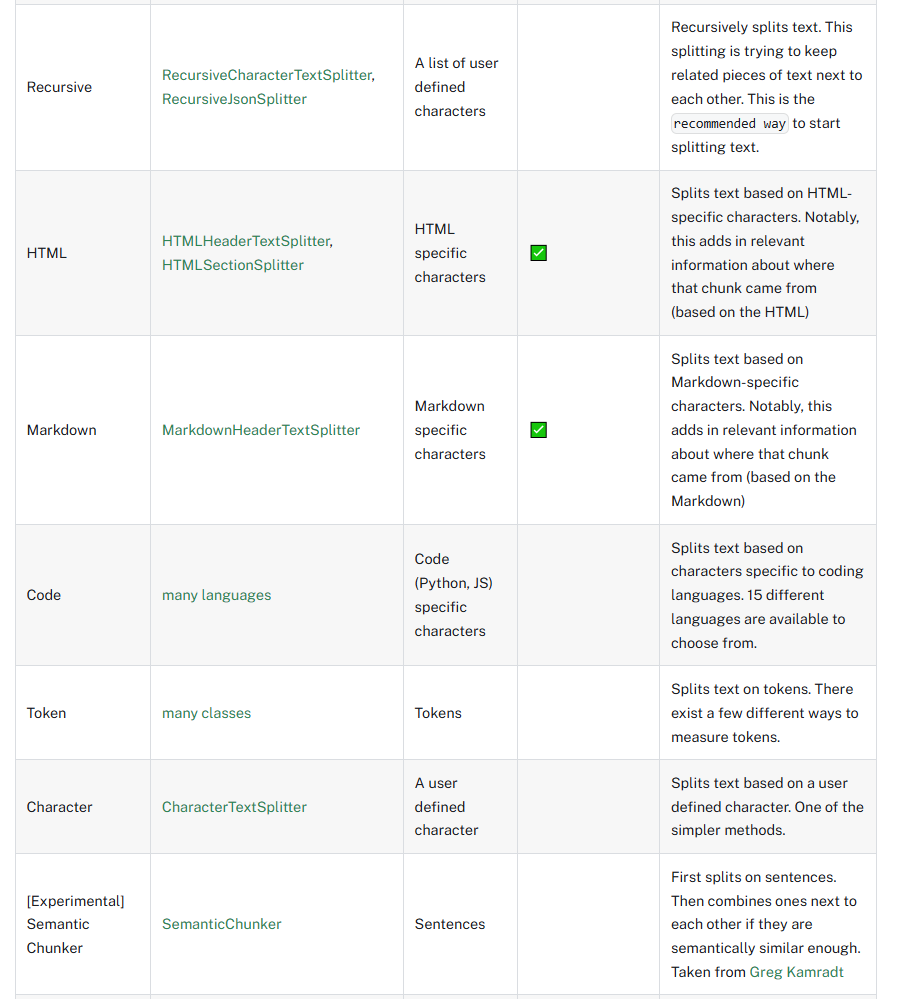

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

### Векторизация текстов

In [ ]:
for i in tqdm(range(len(dataset))):
    text_chunks = text_splitter.split_text(dataset[i]['content'])

    vectors = embedding_model.encode(text_chunks, normalize_embeddings=True, device=device).tolist()

    client.upsert(
        collection_name='kinopoisk_e5',
        points=[
            models.PointStruct(
                id=str(uuid.uuid4()),
                vector=vectors[j],
                payload={
                    'text': text_chunks[j],
                    'movie_name': dataset[i]['movie_name'][:-7],
                    'year': int(dataset[i]['movie_name'][-5:-1]),
                }
            )
            for j in range(len(text_chunks))
        ]
    )

  0%|          | 0/36591 [00:00<?, ?it/s]

/tmp/ipython-input-3281397566.py:6: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Current collection contains 20001 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client.upsert(


Проверим, насколько хорошо ищутся похожие по смыслу тексты.

In [ ]:
query

'В каких фильмах снимался Андриано Челентано?'

In [ ]:
query_vector = embedding_model.encode(query, normalize_embeddings=True, device=device).tolist()

In [ ]:
hits = client.query_points(
    collection_name="kinopoisk_e5",
    query=query_vector,      # или vector=query_vector, зависит от версии
    limit=5
)

In [ ]:
[hit.payload for hit in hits.points]

[{'text': 'Старенький, добрый фильм, с довольно простеньким сценарием и великолепным Челентано.\n\n7 из 10',
  'movie_name': 'Блеф',
  'year': 1976},
 {'text': 'А. Челентано один из самых известных и любимых многими итальянских актёров.\n\nВо всех фильмах у него существует базовый образ итальянского мачо: необычное сочетание интелегентности и грубоватости, некоторой серьёзности и одновременно насмешливости провинциала. К этому базовому образу в каждом фильме он добавляет что-то оригинальное, какую — нибудь необычную деталь характера. Вот почему, не смотря на повторяющееся амплуа «настоящего мужчины», в разных фильмах он выглядит по — разному. \n\nВ этом фильме, безусловно, такой деталью является его образ «жёноненавистника», но в гораздо более мягком смысле, чем мы обычно себе представляем. Не буду пояснять: кому интересно, сам посмотрит и поймёт о чём я.',
  'movie_name': 'Укрощение строптивого',
  'year': 1980},
 {'text': 'Несмотря на то, что картина снята в далеких 80-х гг., да и ещ

In [ ]:
def semantic_search(client, query, limit=10):
    # получаем эмбеддинг запроса
    query_vector = embedding_model.encode(
        query,
        normalize_embeddings=True,
        device=device
    ).tolist()

    # новый API qdrant-client
    res = client.query_points(
        collection_name="kinopoisk_e5",
        query=query_vector,      # вместо query_vector=...
        limit=limit,
        with_payload=True,       # чтобы вернуть payload
        with_vectors=False       # вектора обычно не нужны для ответа
        # если коллекция с именованным вектором, добавь:
        # using="e5",
    )

    # res.points — это список ScoredPoint
    relevant_chunks = [point.payload for point in res.points]

    return relevant_chunks


### RAG на отзывах

Для реализации RAG будем передавать в контекст модели отзывы, относящиеся к запросу.

In [ ]:
def llm_answer(query, context):
    prompt = f"""
    Ты русскоязычный эксперт в области кинематографа. У тебя есть доступ к набору отзывов о фильмах, используй их, чтобы полно и точно ответить на следующий вопрос. Убедись, что ответ подробный, конкретный и непосредственно касается вопроса. Не добавляй информацию, которая не подтверждается предоставленными отзывами.

Вопрос:
{query}

Отзывы:
{context}
"""
    messages = [
        {"role": "user", "content": prompt},
    ]
    output = generation_pipeline(messages, max_new_tokens=512, do_sample=True, temperature=0.9, top_p=0.7)

    return output[0]['generated_text'][1]['content']

In [ ]:
def predict(query):
    selected_chunks = semantic_search(client, query)

    # чтобы не упасть, если ничего не найдено
    if not selected_chunks:
        context = "Отзывов по запросу не найдено."
    else:
        context = " ; ".join(
            f"Отзыв: {chunk['text']}" for chunk in selected_chunks
        )

    return llm_answer(query, context)

In [ ]:
print(predict(query))

Андриано Челентано снимался в следующих фильмах:

1. "Римская любовь" (Roma Love Story) - 1973 год.
2. "Блеф" (Bela Lugosi's Dead) - 1985 год.
3. "Последний раз" (The Last Time) - 1987 год.
4. "Моя жизнь с Эмилией" (My Life with Emily) - 1988 год.
5. "Мой новый дом" (My New Home) - 1989 год.
6. "Я и Том" (And the Birds Fly South) - 1990 год.
7. "Мой новый дом" (My New Home) - 1990 год.
8. "Время любви" (Time for Love) - 1991 год.
9. "Свадьба с Феликсом" (Felix and Me) - 1992 год.
10. "Мой новый дом" (My New Home) - 1992 год.


Несмотря не подсказки, получилось так себе. Дело в том, что отзывы очень редко содержат сами названия фильмов. Попробуем добавить их тоже в контекст.

### Добавляем названия фильмов

In [ ]:
def predict(query):
    selected_chunks = semantic_search(client, query)
    context = ' ; '.join([f"Название: {chunk['movie_name']}. Отзыв: {chunk['text']}" for chunk in selected_chunks])

    return llm_answer(query, context)

In [ ]:
print(predict(query))

Андреано Челентано снимался в следующих фильмах:

1. "Блеф" - 1974 год.
2. "Укрощение строптивого" - 1975 год.
3. "Безумно влюбленный" - 1980 год.
4. "Блеф" - 1993 год.
5. "Укрощение строптивого" - 1997 год.
6. "Блеф" - 2001 год. 
7. "Блеф" - 2006 год.
8. "Блеф" - 2010 год.
9. "Блеф" - 2014 год.


Теперь модель возвращает все фильмы, в которых Андриано Челентано действительно играл и не только...

## Улучшаем RAG

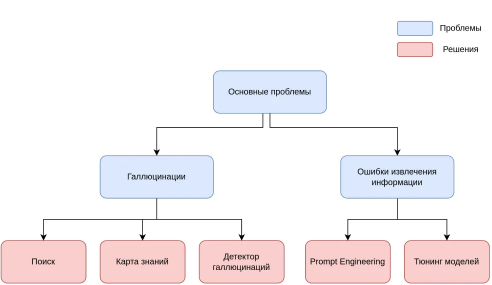

### Re-ranking

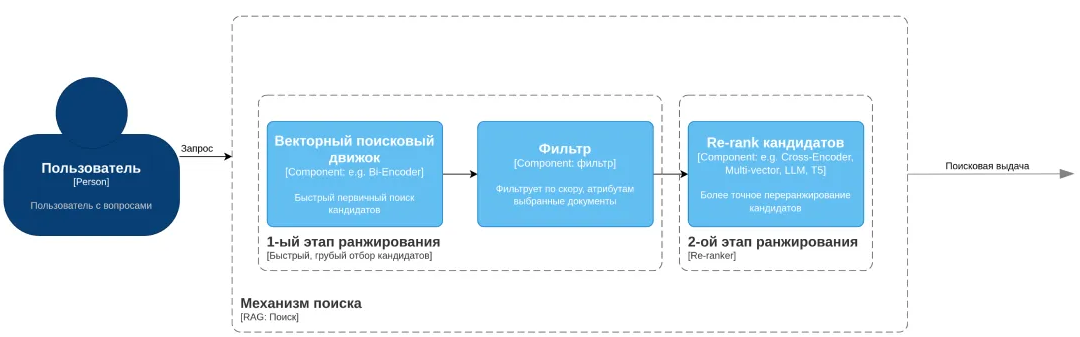




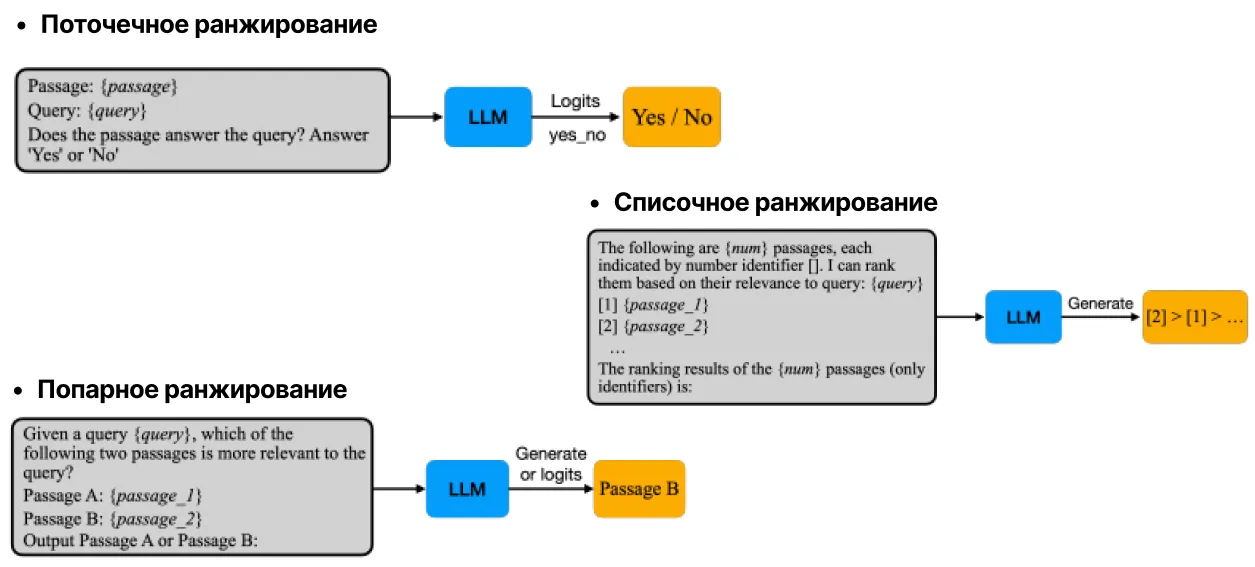

В качестве реранкера мы будем использовать специальную мультиязычную модель, обученную для этих целей [amberoad/bert-multilingual-passage-reranking-msmarco](https://huggingface.co/amberoad/bert-multilingual-passage-reranking-msmarco).

In [ ]:
cross_encoder = HuggingFaceCrossEncoder(
    model_name='amberoad/bert-multilingual-passage-reranking-msmarco',
    model_kwargs={'device': 'cuda' if torch.cuda.is_available() else 'cpu'}
)
sum([p.numel() for p in cross_encoder.client.model.parameters()])

config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/669M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

167357954

In [ ]:
def predict(query):
    selected_chunks = semantic_search(client, query, limit=50)

    texts = [f"Название: {chunk['movie_name']}. Отзыв: {chunk['text']}" for chunk in selected_chunks]
    scores = cross_encoder.score([(query, text) for text in texts])

    idxs = np.argsort(list(scores))[-10:]

    context = ' ; '.join([texts[i] for i in idxs])
    return llm_answer(query, context), context

In [ ]:
query = 'Какие мультфильмы были созданы студией Pixar'

In [ ]:
answer, context = predict(query)

print(answer)

Студия Pixar создала множество мультфильмов, включая:

1. "Валл·И" - робот-уборщик, который влюбляется в другую роботическую фигуру - Еву. 

2. "История игрушек" - история о маленьком игрушечном доме, который отправляется в путешествие и встречает много новых друзей.

3. "Приключение Флика" - история о мальчике, который отправляется на поиски своего друга Флика, который исчез.

4. "Корпорация монстров" - история о группе людей, которые создали монстров для исследования.

5. "В поисках Немо" - история о пингвине, который ищет своего отца.

6. "Тачки" - история о автолюбителях, которые используют своих автомобилей для различных приключений.

7. "Суперсемейка" - история о семье, которая решает перестроить своё домашнее пространство.

8. "Рататуй" - история о животном-ресторане, который предлагает различные блюда для всех, кто хочет поесть.

9. "Вверх" - история о человеке, который возвращается в детство и становится героем своего собственного мультфильма. 

10. "Валл-И" - история о роботе

In [ ]:
context.split(' ; ')

['Название: ВАЛЛ·И. Отзыв: Но в последнее время анимационнное искусство начинает постепенно расширять свои возможности и допускать много ошибок. Некоторые мультфильмы страдают излишками пошлости и плоских шуток, при этом сама мораль проявляется не очень хорошо или попросту отсутствует. Такие картины дети любят только за тупой юмор, им большего и не надо. А это нехорошо. К счастью, к студии Pixar эти недостатки не относятся нисколько. Её визитной карточкой является умение каждый раз выпускать удачный мультфильм. В чём секрет успеха студии? Это слишком глупый вопрос. В данный момент в анимационном искусстве правят мультфильмы, нарисованные на компьютере, а Pixar в этом деле настоящий мастер. Ведь именно эта студия выпустила первый компьютерный мультфильм, который сразу же стал хитом. Последующие работы только укрепляли успех студии. Но среди них, конечно, имеется самая лучшая. И её стоит выделить. По-моему, самым лучшим мультфильмом Pixar является именно «ВАЛЛ·И», и я могу это доказать.'

In [ ]:
query = 'В каких фильмах снимался Андриано Челентано?'
answer, context = predict(query)

print(answer)

Андреа Челентано снимался в следующих фильмах:

1. "Укрощение строптивого" (The Unconquered)
2. "Блеф" (Blef)
3. "Безумно влюбленный" (Madly in Love)
4. "Укрощение строптивого" (The Unconquered)

Также он играл в таких фильмах как "Укрощение строптивого", "Блеф", "Безумно влюбленный".


In [ ]:
context.split(' ; ')

['Название: Укрощение строптивого. Отзыв: Я очень люблю Адриано Челентано. Он виртуоз, и гениален в своем творчестве — и в кино, и в музыке. Фильм «Укрощение строптивого» — достойная оправа его таланту. Элиа — его герой — грубоватый, беспардонный, но честный и работящий владелец фермы. Все его отрицательные черты сглажены невероятным обаянием. Шикарный, безумно привлекательный Челентано… Какие нарекания к нему могут быть? Его мужская энергетика через экраны достигает женских сердец, заставляя их биться чаще. Своей привлекательностью он наделяет и Элию, своего персонажа. На месте Лизы я бы тоже влюбилась и, бросив всё, осталась жить на ферме с Элией. \n\nЛиза в исполнении прекрасной Орнеллы Мути очаровательна и настойчива. Она готова идти на жертвы ради своей любви. И это подкупает Элию. В конце концов ее старания вознаграждены. \n\nЧелентано и Мути роскошно смотрятся вместе, подтверждение этому мы находим не только здесь, но и в фильме «Безумно влюбленный».',
 'Название: Укрощение стро

### Multi-Query

В Multi-Query RAG LLM используется для автоматизации процесса тюнига промптов, чтобы генерировать несколько запросов с разных точек зрения для заданного вопроса, введенного пользователем.

Попробуем расширить контекст, добавив перефразированные вопросы.

Для перефразирования будем использовать ту же модель, которой генерируем текст, но с новым промптом.

In [ ]:
def rephrase_query(query, n=3):
    prompt = f"""
Твоя задача написать {n} разных вариаций вопроса пользователя для того,
чтобы по ним получить релевантные документы из векторной базы данных.
Ты должен переформулировать вопрос с разных точек зрения.
Это поможет избавить пользователя от недостатков поиска похожих документов на основе расстояния.
Вопрос пользователя сфокусирован на теме кино.
Напиши ТОЛЬКО вариации вопроса и больше ничего, разделяя их символом новой строки \\n.
НЕ пиши ответ на сам вопрос.
-----------------
{query}

"""
    messages = [
        {"role": "user", "content": prompt},
    ]
    output = generation_pipeline(messages, max_new_tokens=512, do_sample=True, temperature=0.9, top_p=0.7)
    queries = output[0]['generated_text'][1]['content']

    return re.split(r'\n+', queries)


def predict(query):
    queries = rephrase_query(query, n=3)

    # retrieve documents for each query
    all_chunks = []
    for rephrased_query in queries:
        selected_chunks = semantic_search(client, rephrased_query, limit=5)
        all_chunks.extend(selected_chunks)

    context = [f"Название: {chunk['movie_name']}. Отзыв: {chunk['text']}" for chunk in all_chunks]

    # rerank documents
    scores = cross_encoder.score([(query, text) for text in np.unique(context)])
    idxs = np.argsort(list(scores))[-10:]
    context = ' ; '.join([context[i] for i in idxs])

    # generate answer
    answer = llm_answer(query, context)

    return answer, context, queries

In [ ]:
query = 'Посоветуй легкую комедию'
answer, context, queries = predict(query)

In [ ]:
print(answer)

На основе представленных отзывов, мне кажется, что лучшей легкой комедией для просмотра будет "Гладиатор". Этот фильм получил высокие оценки от многих зрителей, особенно благодаря своей интригой и эмоциональной стороне. Однако, важно помнить, что любое мнение может быть уникальным, поэтому каждый человек может иметь свои предпочтения в кино. Если вам нужен совет, который будет полезен всем, то могу рекомендовать просмотр фильмов "Адвокат дьявола" или "Клуб "Завтрак"", которые также получили положительные отзывы.


Качество Multi-Query во много зависит от способности LLM перефразировать текст. Если она справляется плохо, то появятся нерелевантные запросы. Это можно исправить, добавив фильтрацию по соответствию входному запросу.

In [ ]:
queries

['Расскажи о популярных кинолентах этой категории.',
 'Предложи мне лучший фильм этого года в этом жанре.',
 'Поиск похожих фильмов по расстоянию не подходит, поэтому попробуй предложить что-нибудь, что будет интересно пользователю.']

In [ ]:
context.split(' ; ')

['Название: Гладиатор. Отзыв: На таких фильмах нужно воспитывать поколения!',
 'Название: Матрица. Отзыв: вопросы, которые у вас появились после просмотра этого фильма, не ищите их в продолжениях, вы их не найдёте.',
 'Название: Клуб «Завтрак». Отзыв: И пожалуй это лучшее кино в этом жанре.\n\n10 из 10',
 'Название: Адвокат дьявола. Отзыв: Не возьмусь советовать этот фильм, мои личные представления здесь не сошлись с идеями режиссеров, но тем не менее, фильм неплох!\n\n6 из 10',
 'Название: Клуб «Завтрак». Отзыв: Замечательный фильм, пожалуй, лучший в своем жанре. \n\n10 из 10',
 'Название: Заложница. Отзыв: Подведу итог: «Taken» и «Wanted» Тимура Бекмамбетова, лучшие фильмы этого жанра в этом году. Советую!\n\n10 из 10!',
 'Название: Клуб «Завтрак». Отзыв: И пожалуй это лучшее кино в этом жанре.\n\n10 из 10',
 'Название: Одержимость. Отзыв: Короче говоря, давно не получала столько удовольствия от просмотра фильма! Побольше бы таких картин!\n\n10 из 10',
 'Название: Возвращение мушкете

### Фильтры

Для некоторых видов запросов можно добавить фильтры, чтобы в контекст не могли попадать документы, которые однозначно не подходят.

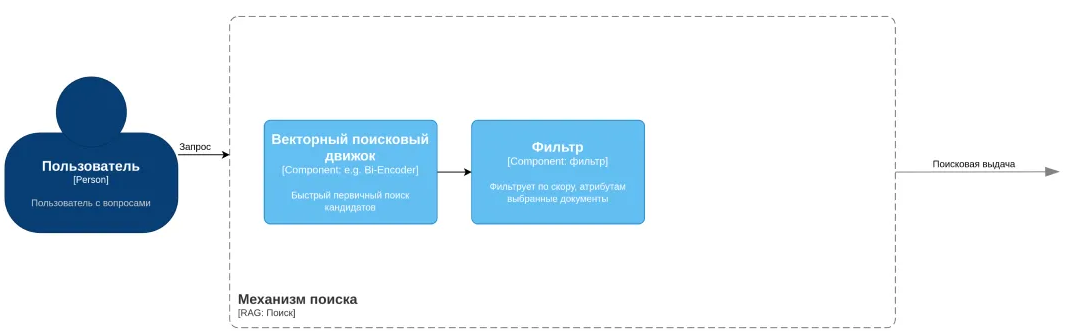

In [ ]:
def predict(query):
    selected_chunks = semantic_search(client, query, limit=10)
    context = ' ; '.join([
        f"Название: {chunk['movie_name']}. Отзыв: {chunk['text']}"
        for chunk in selected_chunks])

    return llm_answer(query, context), context

In [ ]:
query = 'Составь список пяти лучших мелодрам 1980-х годов'
answer, context = predict(query)

In [ ]:
print(answer)

Список пяти лучших мелодрам 1980-х годов:

1. "Привидение" (The Ghost and Mrs. Muir) — фильм, получивший высокую оценку от многих критиков и зрителей. Он был признан лучшим мелодрамой года 1981 года. Фильм рассказывает историю любви между двумя старыми людьми, которые встретились случайно в лунном свете и начали встречаться. Этот романтический сюжет сочетает в себе элементы мистики и драмы.

2. "Крамер против Крамера" (Cramer vs. Kramer) — это трогательная комедия, где два мужчины пытаются сохранить свою семью после судебного процесса по делу о насилии над ребенком. Фильм получил положительные отзывы от зрителей и критиков за свое понимание проблем семейной жизни.

3. "Клуб 'Завтрак'" (Club "Breakfast") — комедийный фильм, который вызвал большой интерес у молодежного publica. Он рассказывает историю друзей-подростков, которые решают создать клуб "Завтрак", чтобы провести свободное время вместе.

4. "Дневник памяти" (Memoirs of a Geisha) — это история о путешествии одной девушки, котора

В этом примере модель сгенерировала не только не мелодрамы, но и фильмы неверных лет

In [ ]:
def filtered_semantic_search(client, query, filter_years, limit=10):
    query_vector = embedding_model.encode(
        query, normalize_embeddings=True, device=device
    ).tolist()

    begin, end = filter_years

    res = client.query_points(
        collection_name="kinopoisk_e5",
        query=query_vector,
        limit=limit,
        query_filter=models.Filter(
            must=[
                models.FieldCondition(
                    key="year",
                    range=models.Range(gte=begin, lte=end),
                )
            ]
        ),
        with_payload=True,
        with_vectors=False
    )

    relevant_chunks = [point.payload for point in res.points]
    return relevant_chunks

def predict(query, filter_years=None):
    if filter_years is not None:
        selected_chunks = filtered_semantic_search(client, query, filter_years=filter_years, limit=10)
    else:
        selected_chunks = semantic_search(client, query, limit=10)

    context = ' ; '.join([f"Название: {chunk['movie_name']}. Отзыв: {chunk['text']}" for chunk in selected_chunks])

    return llm_answer(query, context), context

In [ ]:
answer, context = predict(query, filter_years=(1980, 1989))

In [ ]:
print(answer)

На основе представленных отзывов, вот мой список пяти лучших мелодрам 1980-х годов:

1. "Однажды в Америке" - В этом фильме мы увидим множество персонажей, которые являются уникальными, но они все объединены общими ценностями и чувствами. Этот фильм также отличается своей длительностью, что может сделать его немного сложно пересматривать.

2. "Ганди" - Эта драма, которую советует автор, является одним из самых значимых фильмов 1980-х годов. Она была признана шедевром мирового кинематографа и одна из лучших картин этого десятилетия.

3. "Клуб "Завтрак" - Этот фильм является классическим шедевром 1980-х годов и представляет собой смесь различных элементов - драмы, комедии и юмора. 

4. "Назад в будущее" - Этот фильм является продолжением одного из лучших фантастических приключенческих фильмов 1980-х годов. Он был признан гениальным продолжением и имеет большое количество сцен, которые можно пересматривать бесконечное количество раз.

5. "Общество мертвых поэтов" - Этот фильм является уни

## Оценка качества

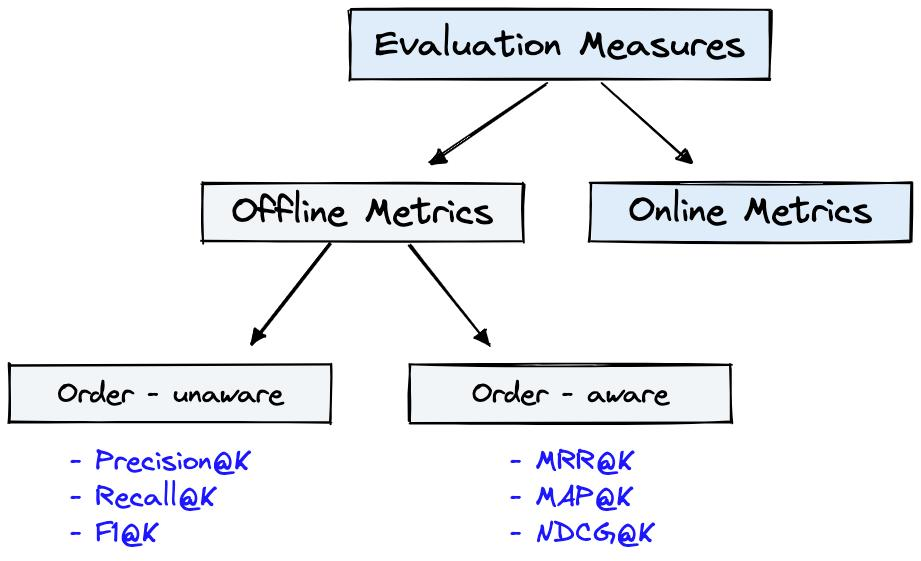



*   Качество поиска
     * Онлайн и оффлайн метрики. Первые считаются в процессе взаимодействия пользователя с поисковой системой, а вторые — перед её выпуском. Оффлайн метрики делятся на те, которые учитывают порядок (MAP@K, NDCG@K) и нет (точность, полнота, F1-score).
*   Качество ответов: полезность
     * читаемость (чем легче читать, тем легче воспринимать);
     * полнота (ответ должен быть исчерпывающим);
     * актуальность (информация не должна быть устаревшей);
     * уместность (ответ должен соответствовать запросу).
*   Качество ответов: этичность
     * отсутствие опасной/оскорбительной инфо;
     * эмоциональная нейтральность;
     * отсутствие неуместного контента.
*   Качество ответов: достоверность
     * фактические ошибки;
     * верифицируемость информации;
     * неактуальные данные;
     * субъективное мнение;
     * категоричность в вопросах религии/эзотерики;
     * противоречия.
___

- можно оценивать качество с помощью LLM
- в качестве ориентира можно использовать прокси-метрики (ROUGE, METEOR, BLEU, Perplexity, BertScore, BLEURT, BARTScore)
- можно использовать автоматическую оценку [**RAGAS**](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/)



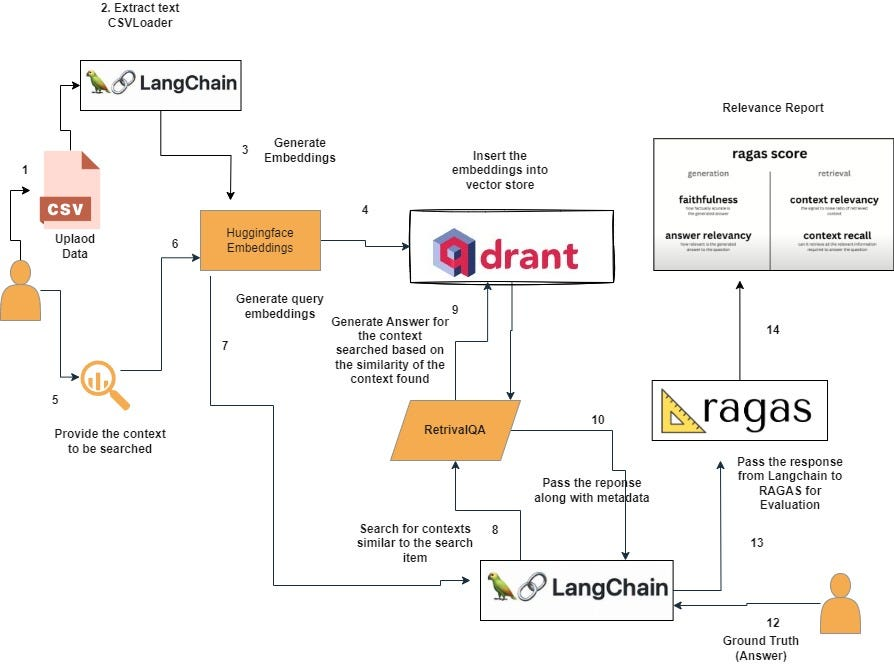

Инструменты для визуализации чанков:

[Chunkviz](https://chunkviz.up.railway.app/)

[RAG Playground](https://ragplay.vercel.app/experiment)

[Pre-processing playground](https://neumai-playground.streamlit.app/)



**Precision@K**
Доля релевантных документов среди первых K результатов.
Показывает «насколько чистая выдача».
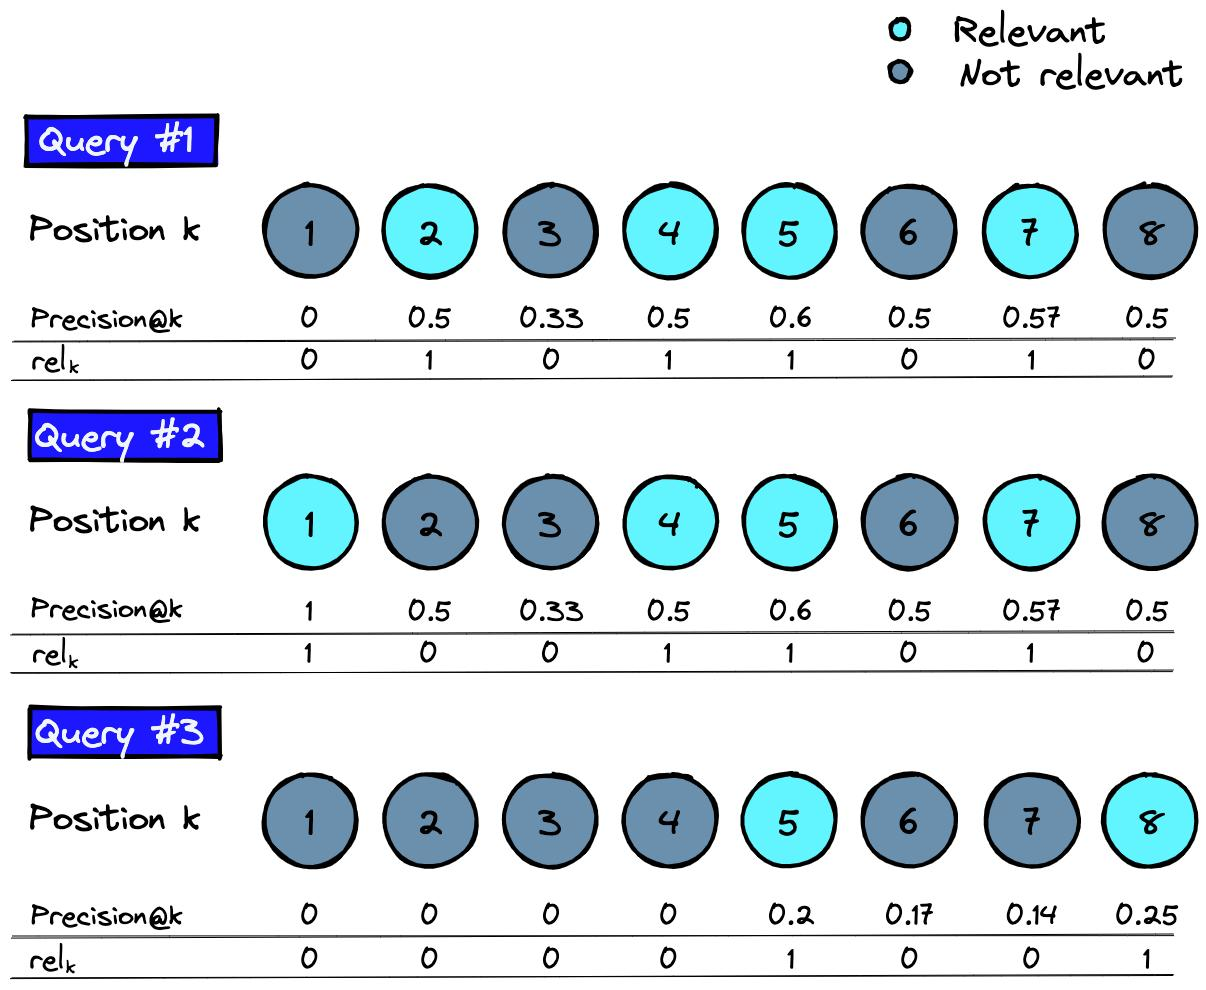

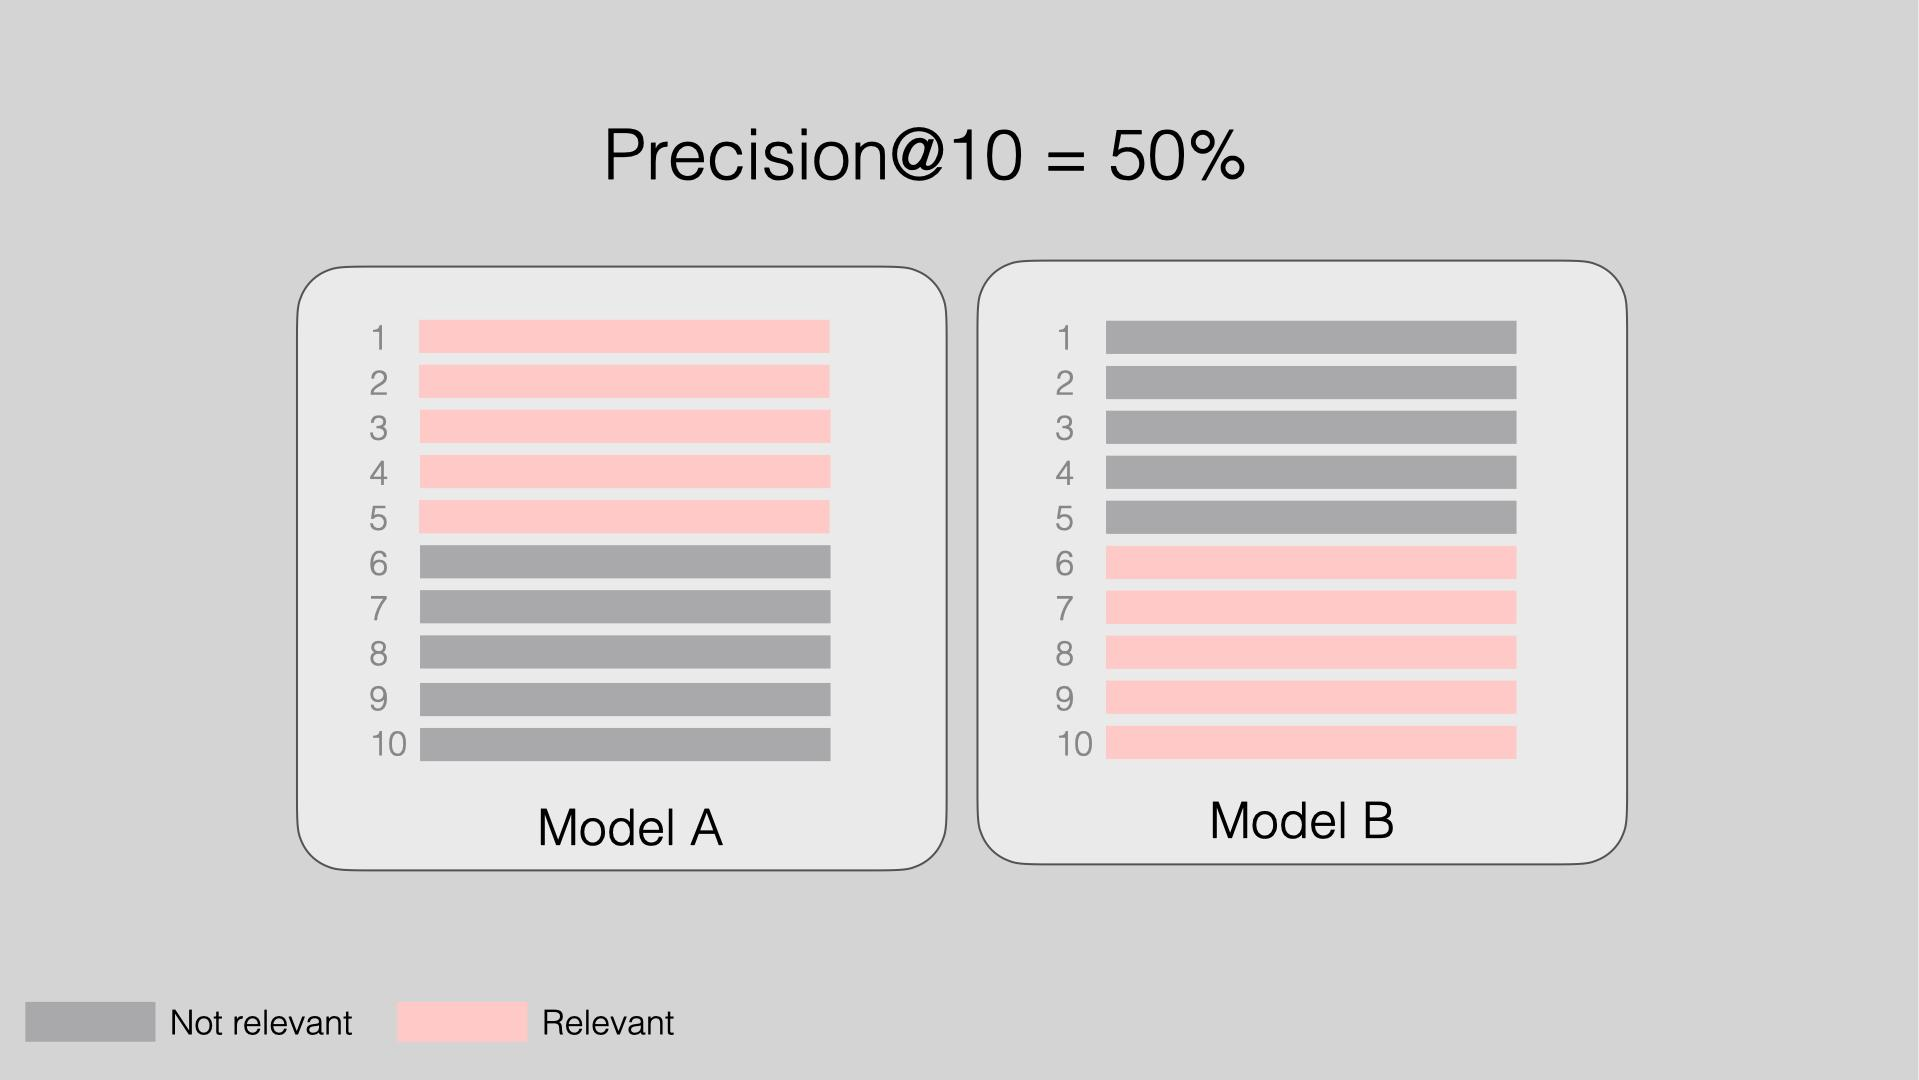

**Сильные стороны:**
Простая метрика, которая учитывает только наличие релевантных результатов среди первых K.

**Слабые стороны:**
- Игнорирует порядок релевантных результатов внутри топ-K. Очень релевантный элемент на позиции 4 оценивается так же, как слабо релевантный на позиции 1.
- Использует бинарную релевантность (релевантно / нерелевантно).

**Recall@K**
Доля найденных релевантных документов среди всех релевантных.
Показывает «насколько полно нашли».
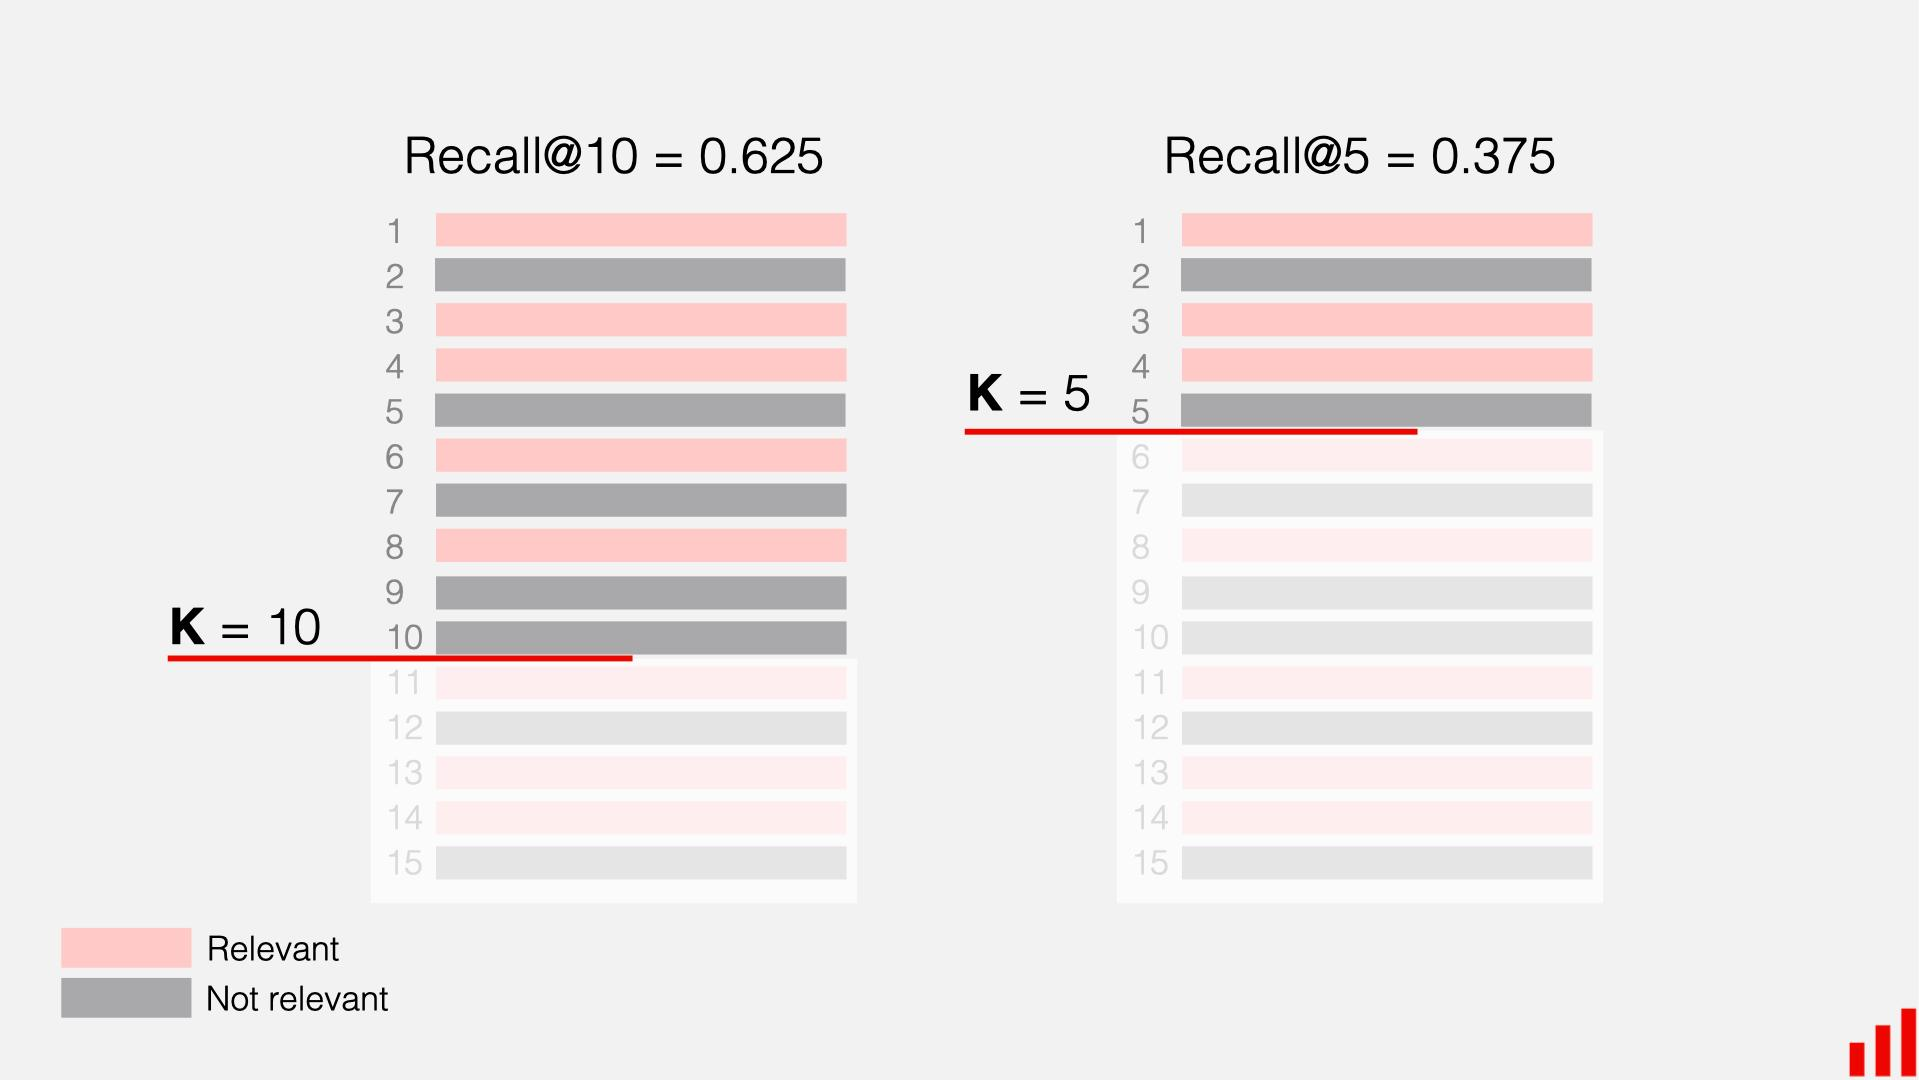


**Сильные стороны:**

- Показывает полноту: насколько система находит все релевантные документы.
- Важна в задачах, где критично ничего не пропустить (поиск документов, медицина, юриспруденция).
Простая и интерпретируемая метрика.

**Слабые стороны:**

- Игнорирует порядок внутри топ-K (релевантный на 1 и на K месте равны).
- Не учитывает «шум» (можно вернуть много нерелевантных, но recall будет высоким).
- Требует знания всех релевантных документов (что часто сложно).

**F1@K** - Гармоническое среднее Precision и Recall.
Баланс между точностью и полнотой.

**Сильные стороны:**

- Балансирует Precision и Recall в одной метрике.
- Полезна, когда важно одновременно качество и полнота.
- Удобна для сравнения моделей одним числом.

**Слабые стороны:**

- Игнорирует порядок результатов (как и Precision/Recall).
- Скрывает дисбаланс: одинаковый F1 может быть при разном Precision и Recall.
- Не учитывает степень релевантности (только бинарная).

**Average Precision** — это средняя точность в точках, где найден релевантный документ.

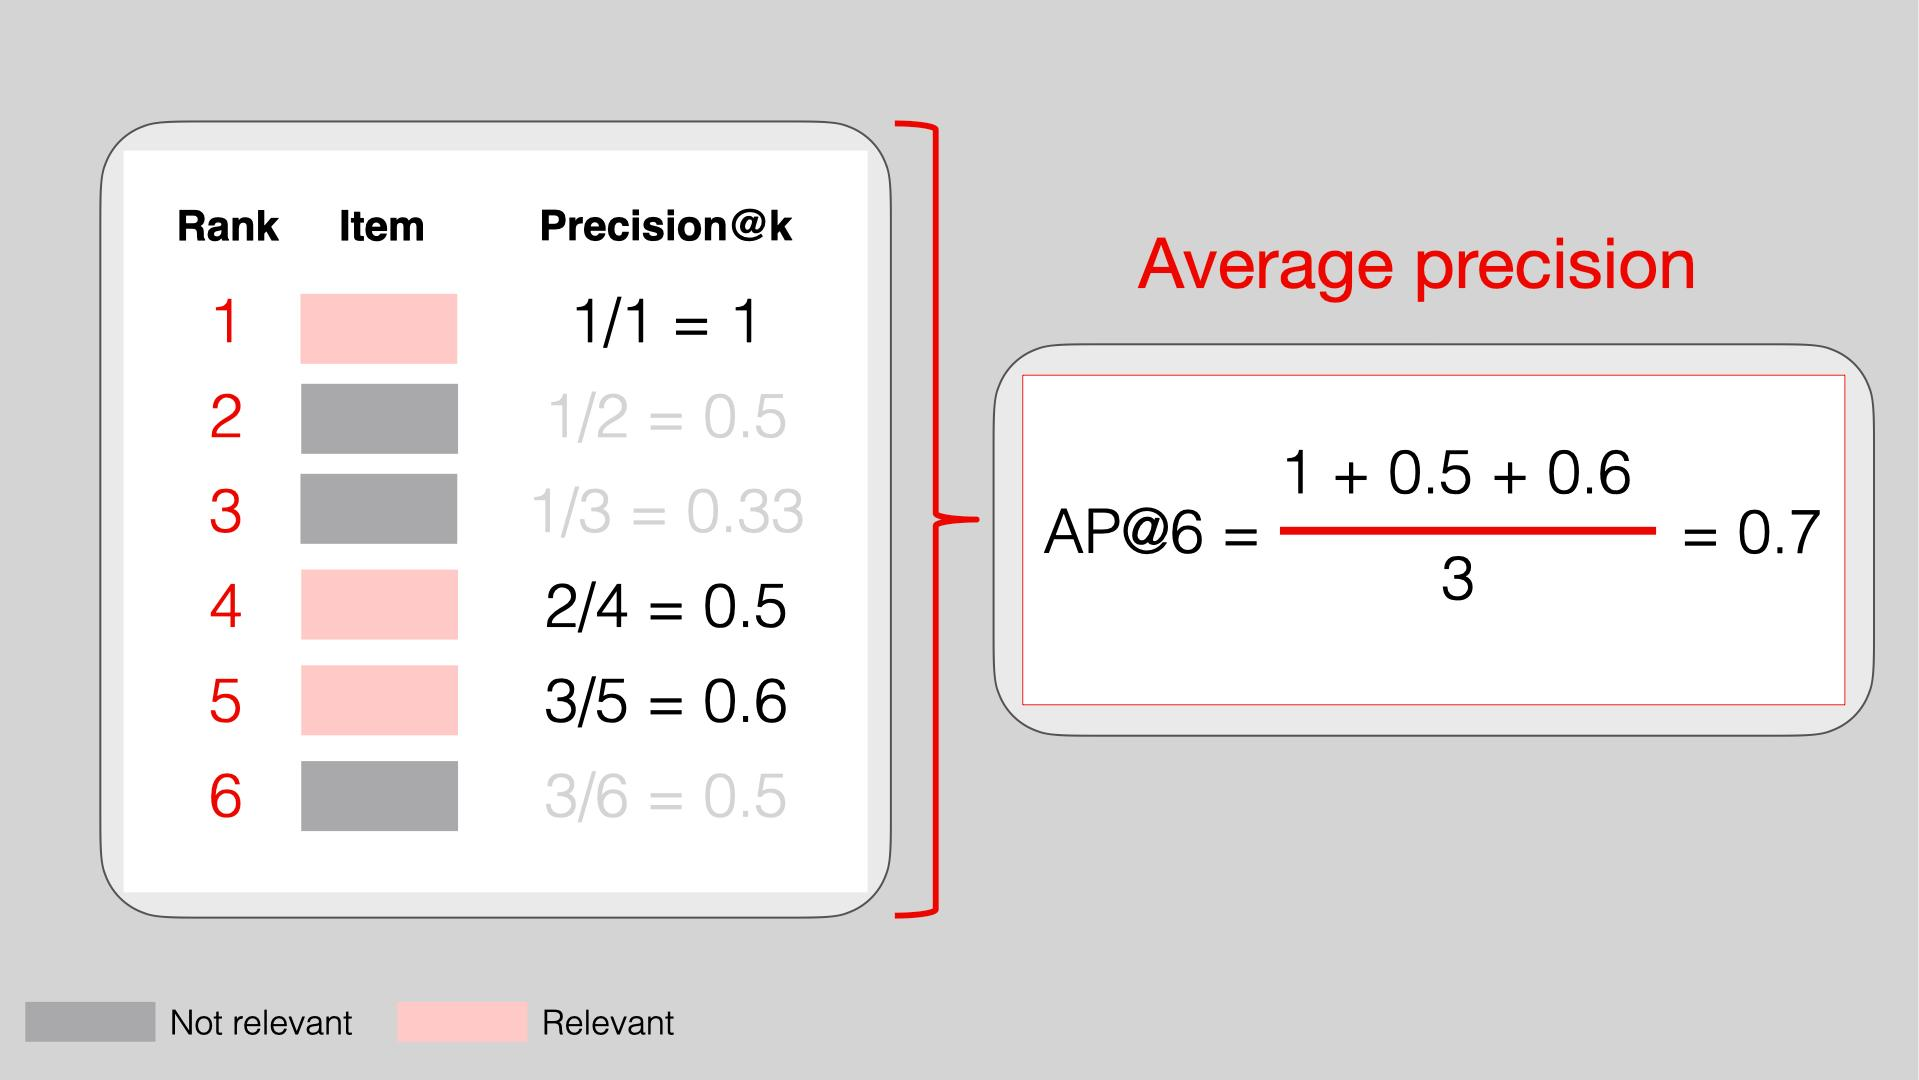

**Сильные стороны:**

- Учитывает порядок ранжирования (релевантные сверху дают больший вклад).
- Учитывает все релевантные документы, а не только первый (в отличие от MRR).
- Хорошо отражает качество retrieval: штрафует «размазанные» по списку релевантные.
- Интерпретируемая логика: «средний Precision в точках попадания».
- Является основой для MAP — стандартной метрики в поиске.

**Слабые стороны:**

- Использует только бинарную релевантность (нет градаций качества).
- Требует знания всех релевантных документов (в реальности это часто недоступно).
- Чувствительна к неполной или шумной разметке.
- Менее интуитивна для интерпретации, чем Precision@K или Recall@K.
- Может переоценивать качество, если релевантных документов мало.

**MRR (Mean Reciprocal Rank)**
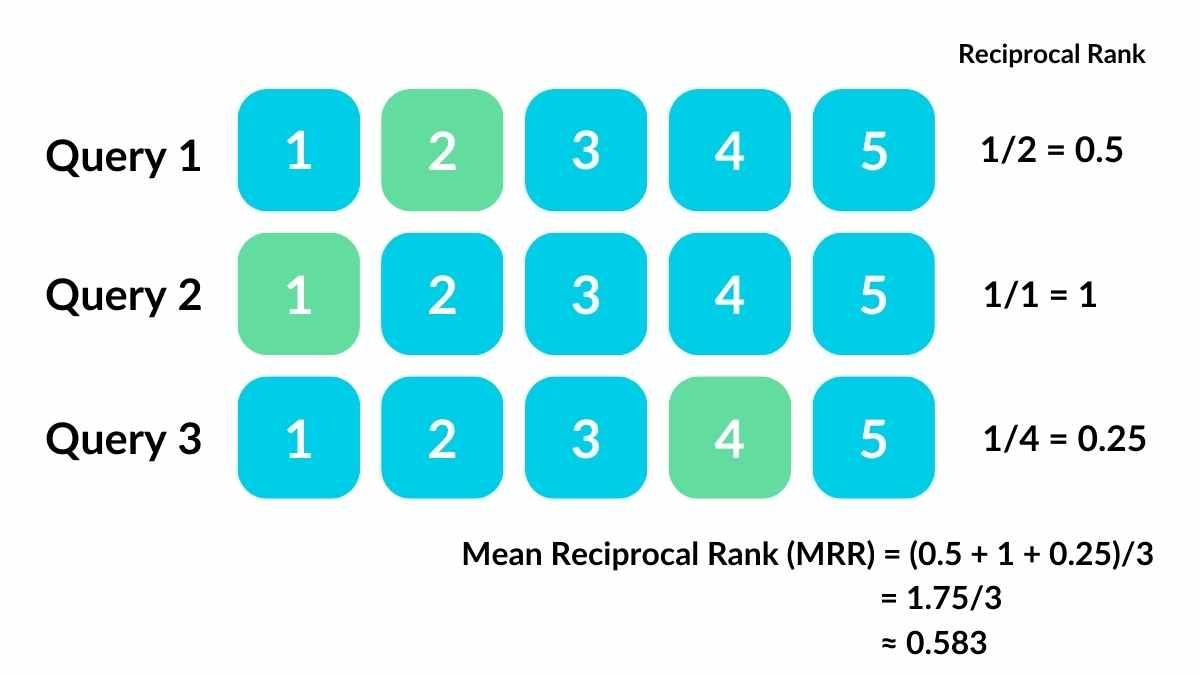

**Сильные стороны:**
- Простая метрика, показывающая, насколько рано в выдаче появляется первый релевантный результат.
- Хорошо подходит для оценки задач поиска известного объекта (known-item search) и навигационного поиска.

**Слабые стороны:**
- Ограниченно отражает общую релевантность. Высокий MRR может означать лишь то, что первый результат релевантен, но ничего не говорит о качестве остальных.
- Использует бинарную релевантность (релевантно / нерелевантно).
- Малоинформативна при большом числе результатов.

**NDCG (Normalized Discounted Cumulative Gain)** - измеряет насколько хорош порядок результатов с учётом их полезности.

**Учитывает:**

позицию (чем выше — тем лучше) и степень релевантности (не только 0/1, а например 0–3)
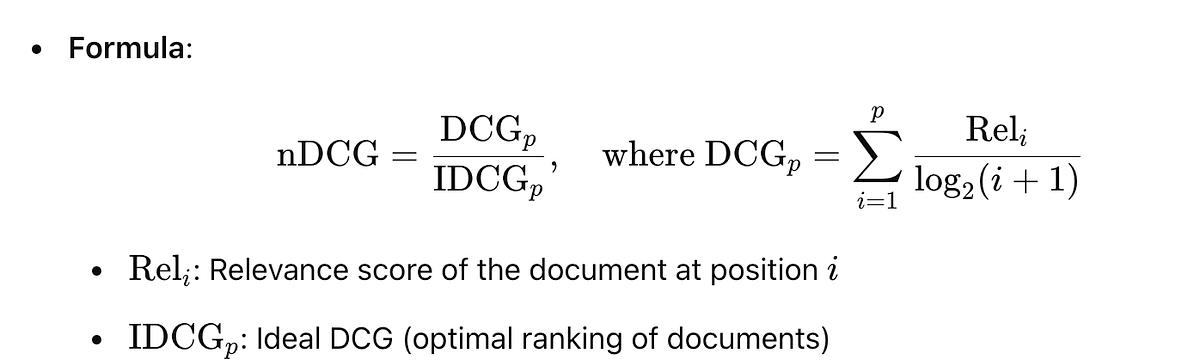

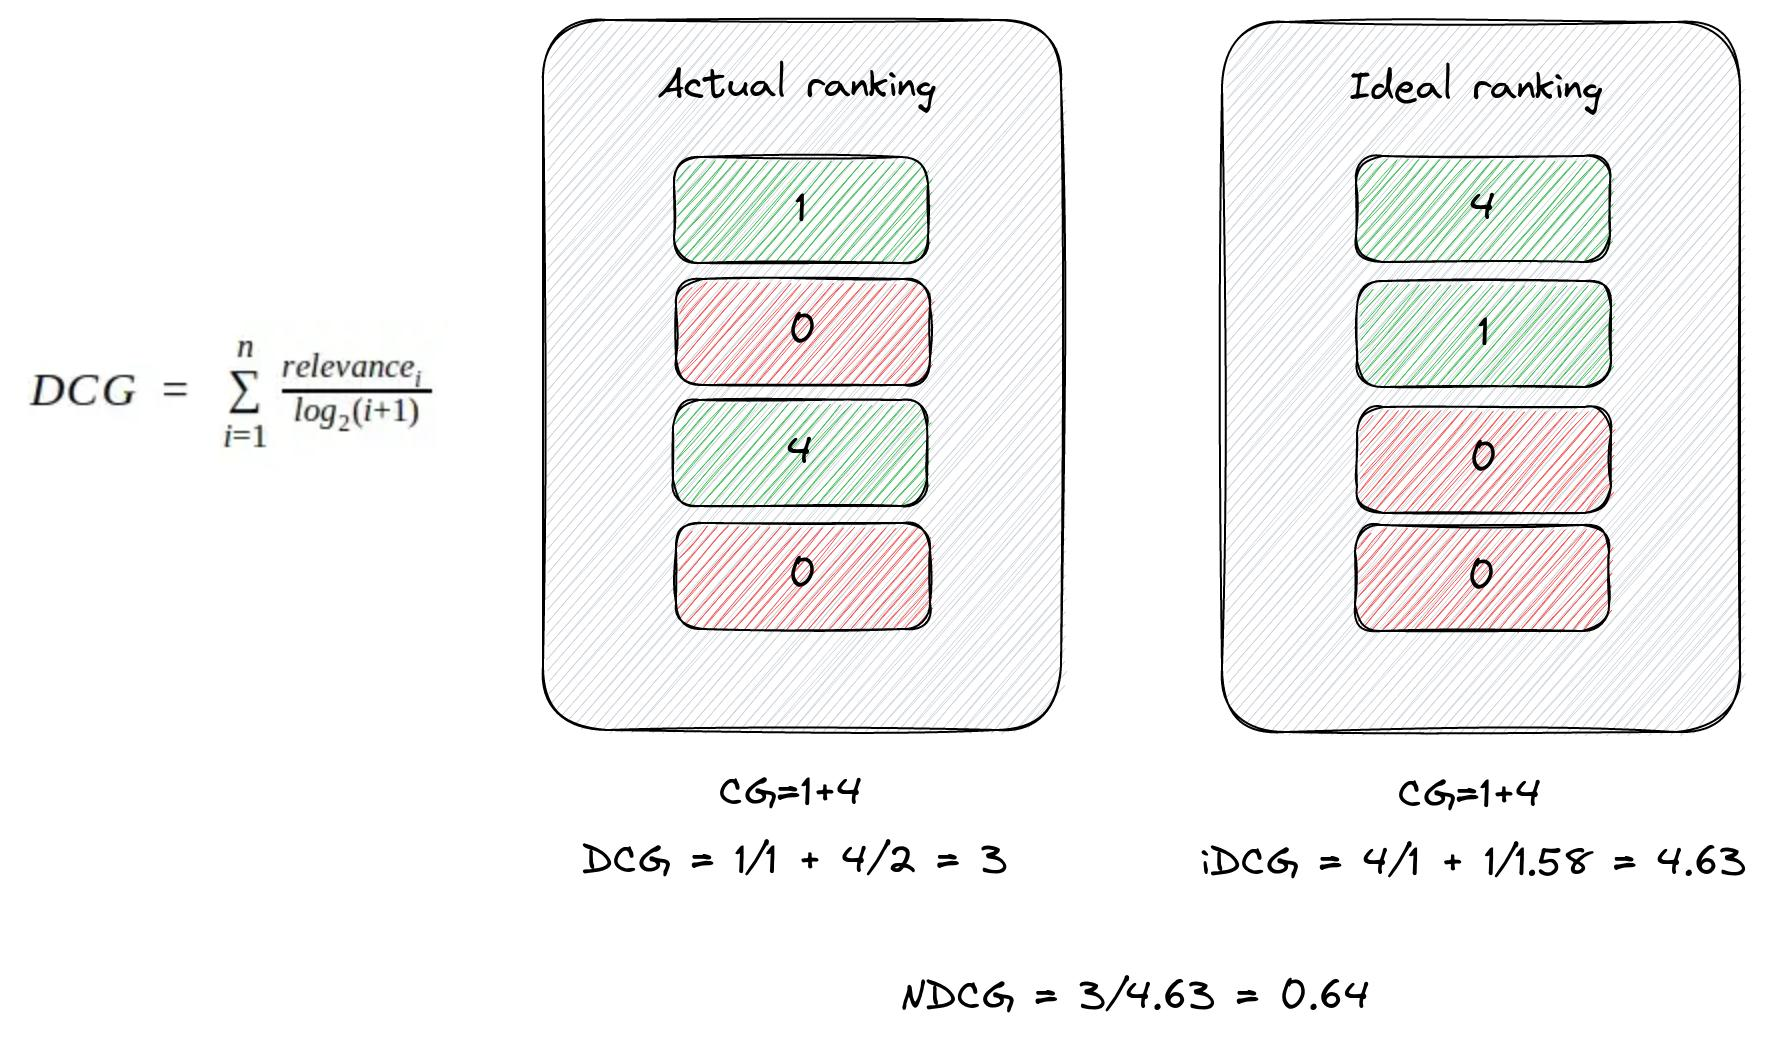


**Сильные стороны:**
- Учитывает порядок ранжирования результатов.
- Поддерживает градуированную релевантность (разную степень полезности), выходя за рамки бинарного «релевантно / нерелевантно».
- Подходит для оценки веб-поиска.

**Слабые стороны:**
- Сложнее в интерпретации по сравнению с другими метриками, требует понимания формул.
- Может возникать проблема согласованности оценок между экспертами (Inter-Rater Reliability, IRR).